<a href="https://colab.research.google.com/github/Danny23-bioenergy/yacouba-loop-simulation/blob/main/simulation_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌿 THE YACOUBA LOOP: Integrated Desert Restoration
Simulating 5 Rainy Months (Sahel Season)

Starting Biomass (kg/ha): 800
Livestock Count: 0.7
Deploy Yacouba Loop? (yes/no): yes

--- Month 1 ---
Water retained bonus : +40.3kg
Biochar/manure bonus : +5.8kg
Rain: 21mm | Field Biomass: 767.0kg

--- Month 2 ---
Water retained bonus : +46.1kg
Biochar/manure bonus : +5.8kg
Rain: 24mm | Field Biomass: 747.1kg

--- Month 3 ---
Water retained bonus : +49.9kg
Biochar/manure bonus : +5.8kg
Rain: 26mm | Field Biomass: 735.7kg

--- Month 4 ---
Water retained bonus : +96.0kg
Biochar/manure bonus : +5.8kg
Rain: 50mm | Field Biomass: 828.0kg

--- Month 5 ---
Water retained bonus : +65.3kg
Biochar/manure bonus : +5.8kg
Rain: 34mm | Field Biomass: 851.2kg

--- Final Land Health ---
Result: UNDER STRESS — Restoration recommended

--- Data Sources ---
FAO/GIEWS Sahel Report
Lehmann & Joseph (2015)
UNCCD Sahelian Field Data (2024)
FAO Copernicus Biomass Data


/tmp/ipykernel_15691/1439446448.py:82: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


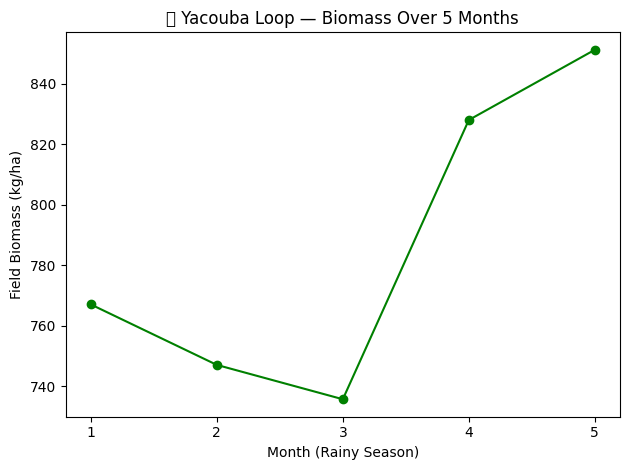

In [1]:
#Author = Danny Nawa Myunda , a student at coppoerbelt university
# i am a independent researcher . one world one people is my goal !!!!


import random
import matplotlib.pyplot as plt

# --- SCIENCE CONSTANTS ---
MONTHLY_CONSUMPTION = 185  # kg per animal (FAO Standard)
SAHEL_GROWTH_COEFF = 2.4   # kg of grass per 1mm of rain
MANURE_RATE = 0.30         # 30% of consumed grass becomes manure
BIOCHAR_CONVERSION = 0.15  # 15% of manure converts to biochar benefit
# Note: 15% is an optimistic estimate accounting for losses due to
# weathering, collection inefficiency, and drying before pyrolysis.
RESTORATION_BOOST = 0.8    # 80% average synergy (Zai Pits + Biochar)


def get_inputs():
    print("🌿 THE YACOUBA LOOP: Integrated Desert Restoration")
    print("Simulating 5 Rainy Months (Sahel Season)\n")
    grass = int(input("Starting Biomass (kg/ha): "))
    animals = float(input("Livestock Count: "))
    system_active = input("Deploy Yacouba Loop? (yes/no): ").lower()
    return grass, animals, system_active


def simulate_month(grass, animals, system_active):
    # Livestock reduce intake when grass is scarce (real Sahel behavior)
    grazing_pressure = min(1.0, grass / (animals * MONTHLY_CONSUMPTION))
    consumed = animals * MONTHLY_CONSUMPTION * grazing_pressure

    if grazing_pressure < 1.0:
        print(f"⚠️  Overgrazing pressure: herd only found {consumed:.1f}kg (field running low)")

    grass = max(0, grass - consumed)

    # Rainfall
    rainfall = random.randint(5, 50)

    # Growth Calculation
    new_growth = rainfall * SAHEL_GROWTH_COEFF

    # The Restoration Synergy
    if system_active == "yes":
        water_bonus = new_growth * RESTORATION_BOOST
        manure_kg = consumed * MANURE_RATE
        biochar_bonus = manure_kg * BIOCHAR_CONVERSION
        new_growth += water_bonus + biochar_bonus
        print(f"Water retained bonus : +{water_bonus:.1f}kg")
        print(f"Biochar/manure bonus : +{biochar_bonus:.1f}kg")

    grass = max(0, grass + new_growth)
    print(f"Rain: {rainfall}mm | Field Biomass: {grass:.1f}kg")

    return grass


def print_final_health(grass):
    print("\n--- Final Land Health ---")
    if grass > 2000:
        print("Result: THRIVING (Desert Pushed Back)")
    elif grass >= 1000:
        print("Result: STABLE — Holding ground")
    elif grass >= 500:
        print("Result: UNDER STRESS — Restoration recommended")
    else:
        print("Result: DEGRADED (Needs Restoration)")

    print("\n--- Data Sources ---")
    print("FAO/GIEWS Sahel Report")
    print("Lehmann & Joseph (2015)")
    print("UNCCD Sahelian Field Data (2024)")
    print("FAO Copernicus Biomass Data")


def plot_results(months, biomass_history):
    plt.plot(months, biomass_history, color="green", marker="o")
    plt.xlabel("Month (Rainy Season)")
    plt.ylabel("Field Biomass (kg/ha)")
    plt.title("🌿 Yacouba Loop — Biomass Over 5 Months")
    plt.xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.show()


# --- MAIN PROGRAM ---
grass, animals, system_active = get_inputs()

months = []
biomass_history = []

for month in range(1, 6):
    print(f"\n--- Month {month} ---")
    grass = simulate_month(grass, animals, system_active)
    months.append(month)
    biomass_history.append(grass)

print_final_health(grass)
plot_results(months, biomass_history)